# 02 — Preprocessing Pipeline

**CRITICAL:** This exact pipeline is replicated verbatim in `backend/predict.py`.
Any drift between training and inference = wrong predictions.

Steps:
1. Drop constant sensors
2. Compute & cap RUL at 125
3. MinMaxScaler fit on train only — save `scaler.pkl`
4. Sliding window sequences (length=30)
5. Save `X_train.npy`, `y_train.npy`, `X_test.npy`, `y_test.npy`

In [1]:
import numpy as np
import pandas as pd
import joblib
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler

DATA_DIR = Path('../data/raw')
PROC_DIR = Path('../data/processed')
PROC_DIR.mkdir(exist_ok=True)

# ── Hyperparameters (single source of truth) ──────────────────────────────
SEQUENCE_LENGTH = 30
RUL_CAP = 125

# Sensors with near-zero variance in FD001 — determined from 01_EDA.ipynb
DROP_SENSORS = ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10',
                'sensor_16', 'sensor_18', 'sensor_19']

COLUMNS = (
    ['engine_id', 'cycle', 'op_set_1', 'op_set_2', 'op_set_3'] +
    [f'sensor_{i}' for i in range(1, 22)]
)

FEATURE_COLS = None  # will be set after dropping sensors

In [2]:
def load_raw(subset='FD001'):
    train = pd.read_csv(
        DATA_DIR / f'train_{subset}.txt',
        sep=r'\s+', header=None, names=COLUMNS
    )
    test = pd.read_csv(
        DATA_DIR / f'test_{subset}.txt',
        sep=r'\s+', header=None, names=COLUMNS
    )
    rul_test = pd.read_csv(
        DATA_DIR / f'RUL_{subset}.txt',
        sep=r'\s+', header=None, names=['rul']
    )['rul'].values
    return train, test, rul_test

train_raw, test_raw, rul_test_true = load_raw('FD001')
print(f'Loaded: train={train_raw.shape}, test={test_raw.shape}')

Loaded: train=(20631, 26), test=(13096, 26)


In [3]:
# ── Step 1: Drop constant sensors ─────────────────────────────────────────
op_cols = ['op_set_1', 'op_set_2', 'op_set_3']
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
keep_sensors = [s for s in sensor_cols if s not in DROP_SENSORS]
FEATURE_COLS = op_cols + keep_sensors  # 3 op settings + 14 sensors = 17 features

print(f'Feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}')

Feature columns (17): ['op_set_1', 'op_set_2', 'op_set_3', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


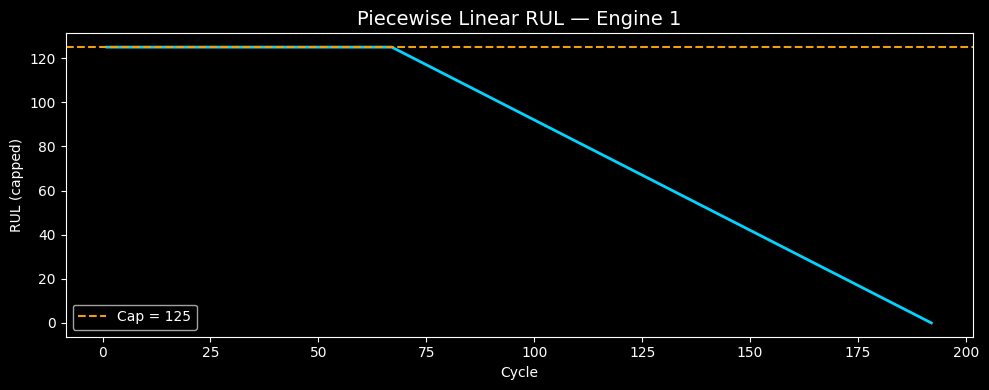

In [4]:
# ── Step 2: Compute RUL (piecewise linear — cap at RUL_CAP) ───────────────
def add_rul(df, cap=RUL_CAP):
    max_cycle = df.groupby('engine_id')['cycle'].max().rename('max_cycle')
    df = df.join(max_cycle, on='engine_id')
    df['rul'] = (df['max_cycle'] - df['cycle']).clip(upper=cap)
    df.drop(columns='max_cycle', inplace=True)
    return df

train = add_rul(train_raw.copy())

import matplotlib.pyplot as plt
plt.style.use('dark_background')
sample = train[train['engine_id'] == 1]
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sample['cycle'], sample['rul'], color='#00d4ff', linewidth=2)
ax.axhline(RUL_CAP, color='#f59e0b', linestyle='--', label=f'Cap = {RUL_CAP}')
ax.set_title('Piecewise Linear RUL — Engine 1', fontsize=14)
ax.set_xlabel('Cycle')
ax.set_ylabel('RUL (capped)')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/rul_piecewise.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# ── Step 3: Fit MinMaxScaler on TRAINING data only ─────────────────────────
scaler = MinMaxScaler()
train[FEATURE_COLS] = scaler.fit_transform(train[FEATURE_COLS])
# Apply same scaler to test — DO NOT refit
test_raw[FEATURE_COLS] = scaler.transform(test_raw[FEATURE_COLS])

# Save scaler — MUST be loaded by backend/predict.py
joblib.dump({'scaler': scaler, 'feature_cols': FEATURE_COLS,
             'drop_sensors': DROP_SENSORS, 'sequence_length': SEQUENCE_LENGTH,
             'rul_cap': RUL_CAP},
            '../backend/model/scaler.pkl')
print('Saved scaler.pkl with metadata')

Saved scaler.pkl with metadata


In [6]:
# ── Step 4: Sliding window sequence extraction ─────────────────────────────
def make_sequences(df, feature_cols, seq_len=SEQUENCE_LENGTH, has_rul=True):
    """Extract overlapping windows of length seq_len per engine."""
    X, y = [], []
    for eng_id, grp in df.groupby('engine_id'):
        feats = grp[feature_cols].values
        if has_rul:
            ruls = grp['rul'].values
        n = len(feats)
        for i in range(n - seq_len + 1):
            X.append(feats[i:i + seq_len])
            if has_rul:
                y.append(ruls[i + seq_len - 1])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32) if has_rul else None

X_train, y_train = make_sequences(train, FEATURE_COLS)
print(f'X_train: {X_train.shape}  →  (samples, {SEQUENCE_LENGTH}, {len(FEATURE_COLS)})')
print(f'y_train: {y_train.shape}')

X_train: (17731, 30, 17)  →  (samples, 30, 17)
y_train: (17731,)


In [7]:
# ── Test set: one sequence per engine (last seq_len cycles) ───────────────
def make_test_sequences(df, feature_cols, seq_len=SEQUENCE_LENGTH):
    """For test set: take the LAST seq_len rows per engine."""
    X = []
    for eng_id, grp in df.groupby('engine_id'):
        feats = grp[feature_cols].values
        if len(feats) >= seq_len:
            X.append(feats[-seq_len:])
        else:
            # Pad with first row if too short
            pad = np.tile(feats[0], (seq_len - len(feats), 1))
            X.append(np.vstack([pad, feats]))
    return np.array(X, dtype=np.float32)

X_test = make_test_sequences(test_raw, FEATURE_COLS)
y_test = np.clip(rul_test_true, 0, RUL_CAP).astype(np.float32)
print(f'X_test: {X_test.shape}')
print(f'y_test: {y_test.shape}')

X_test: (100, 30, 17)
y_test: (100,)


In [8]:
# ── Step 5: Save processed arrays ─────────────────────────────────────────
np.save(PROC_DIR / 'X_train.npy', X_train)
np.save(PROC_DIR / 'y_train.npy', y_train)
np.save(PROC_DIR / 'X_test.npy', X_test)
np.save(PROC_DIR / 'y_test.npy', y_test)

print('Saved:')
print(f'  X_train.npy  {X_train.shape}')
print(f'  y_train.npy  {y_train.shape}')
print(f'  X_test.npy   {X_test.shape}')
print(f'  y_test.npy   {y_test.shape}')
print(f'\nPipeline config saved in scaler.pkl:')
print(f'  SEQUENCE_LENGTH = {SEQUENCE_LENGTH}')
print(f'  RUL_CAP         = {RUL_CAP}')
print(f'  DROP_SENSORS    = {DROP_SENSORS}')
print(f'  FEATURE_COLS    = {FEATURE_COLS}')

Saved:
  X_train.npy  (17731, 30, 17)
  y_train.npy  (17731,)
  X_test.npy   (100, 30, 17)
  y_test.npy   (100,)

Pipeline config saved in scaler.pkl:
  SEQUENCE_LENGTH = 30
  RUL_CAP         = 125
  DROP_SENSORS    = ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
  FEATURE_COLS    = ['op_set_1', 'op_set_2', 'op_set_3', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
